# Synthetic v1 vs v2 — sample visualisation

Side-by-side look at the two synthetic repetition-counting datasets. v1 is a pure cosine across the whole clip; v2 adds:

1. **Variable active span** — the dot oscillates only over a sub-window `[start, start+m)` of length `m ∈ [min_active_frames, n_frames]` and is held stationary at the boundary y outside that window.
2. **Non-stationary frequency** — the active span is split into up to `max_segments` contiguous segments with different per-segment cycle counts; phase is continuous across boundaries; the label is the sum.
3. **Trajectory jitter** — small Gaussian noise on the per-frame y position.

No model loading; just rendering and trajectory recovery.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from tasks.repetition.dataset import SyntheticOscillatingDots, SyntheticOscillatingDotsV2

N_FRAMES = 64
IMAGE_SIZE = 64
MAX_COUNT = 16

ds_v1 = SyntheticOscillatingDots(
    n_samples=2048, n_frames=N_FRAMES, image_size=IMAGE_SIZE,
    max_count=MAX_COUNT, split='train',
)
ds_v2 = SyntheticOscillatingDotsV2(
    n_samples=2048, n_frames=N_FRAMES, image_size=IMAGE_SIZE,
    max_count=MAX_COUNT, split='train',
)
print(f'v1 len={len(ds_v1)}, v2 len={len(ds_v2)}')

v1 len=2048, v2 len=2048


## Frame strips

Each row is a clip; columns are 16 evenly-spaced frames. The dot motion across the strip should look like a uniform cosine for v1 and a chunked / windowed cosine for v2.

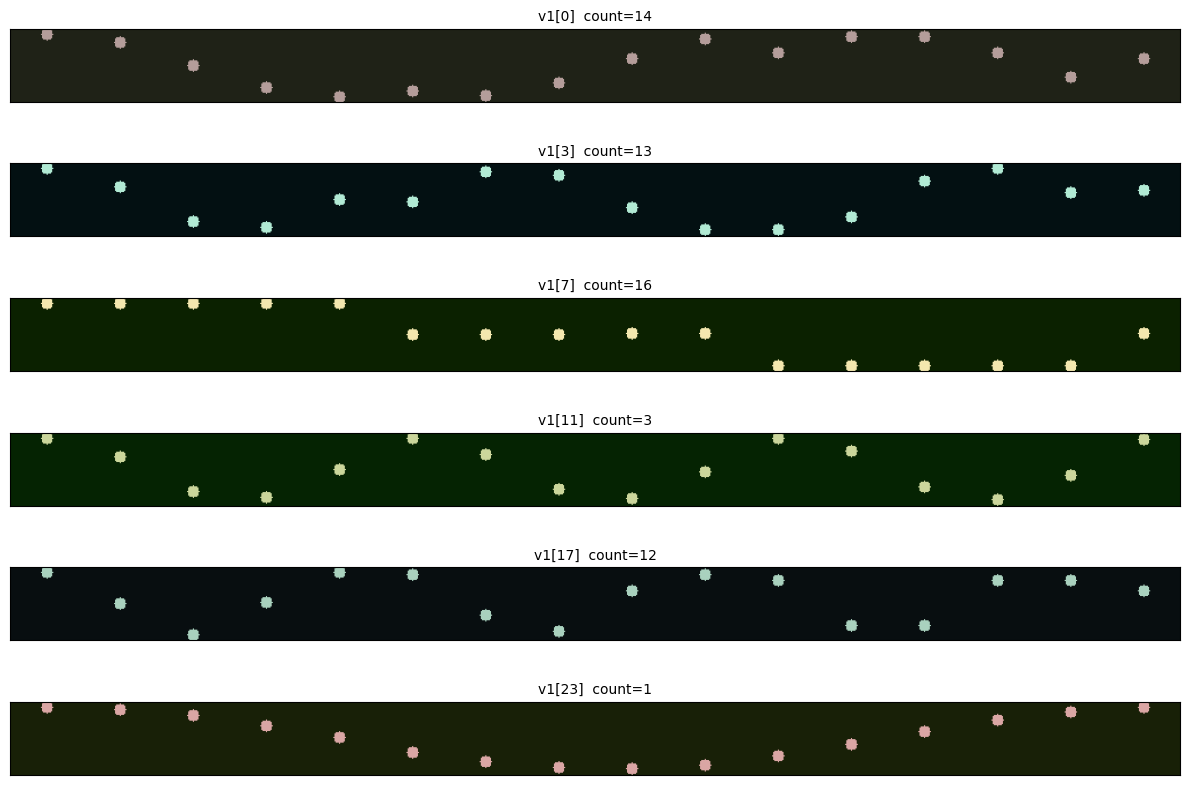

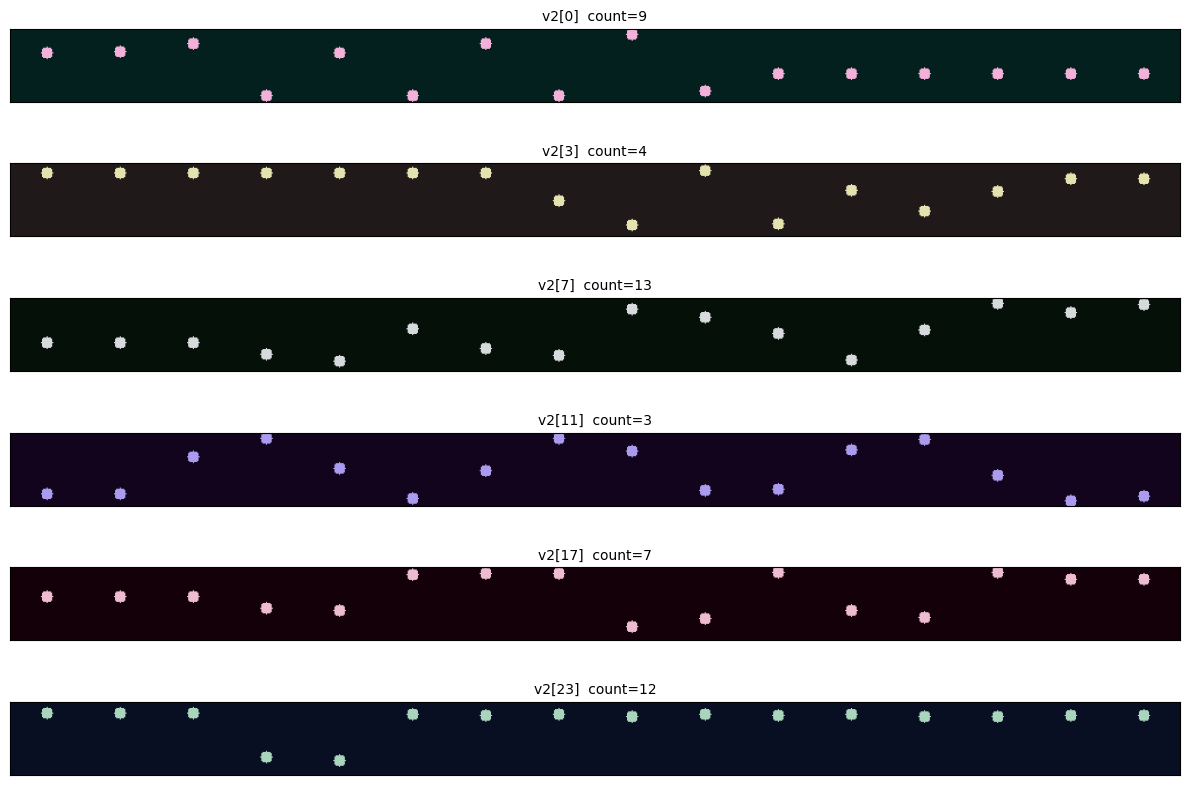

In [2]:
def to_rgb_frames(clip):
    """clip: (T, 3, H, W) in [-1, 1] -> (T, H, W, 3) in [0, 1]."""
    arr = clip.numpy()
    arr = (arr * 0.5 + 0.5).clip(0.0, 1.0)
    return arr.transpose(0, 2, 3, 1)


def show_strip(ax, clip, n_strip=16, title=None):
    arr = to_rgb_frames(clip)
    T = arr.shape[0]
    idx = np.linspace(0, T - 1, n_strip).astype(int)
    strip = np.concatenate([arr[i] for i in idx], axis=1)
    ax.imshow(strip)
    ax.set_xticks([]); ax.set_yticks([])
    if title is not None:
        ax.set_title(title, fontsize=10)


def show_grid(dataset, indices, name):
    fig, axes = plt.subplots(len(indices), 1, figsize=(12, 1.4 * len(indices)))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        clip, count = dataset[idx]
        show_strip(ax, clip, title=f'{name}[{idx}]  count={count}')
    fig.tight_layout()
    plt.show()


INDICES = [0, 3, 7, 11, 17, 23]
show_grid(ds_v1, INDICES, 'v1')
show_grid(ds_v2, INDICES, 'v2')

## y-trajectories

Recover each frame's dot row by `argmax` of the per-row mean luminance along the central column. Easier to compare structure than the strips: v1 = clean cosine; v2 = stationary borders + multi-frequency middle + a hint of jitter.

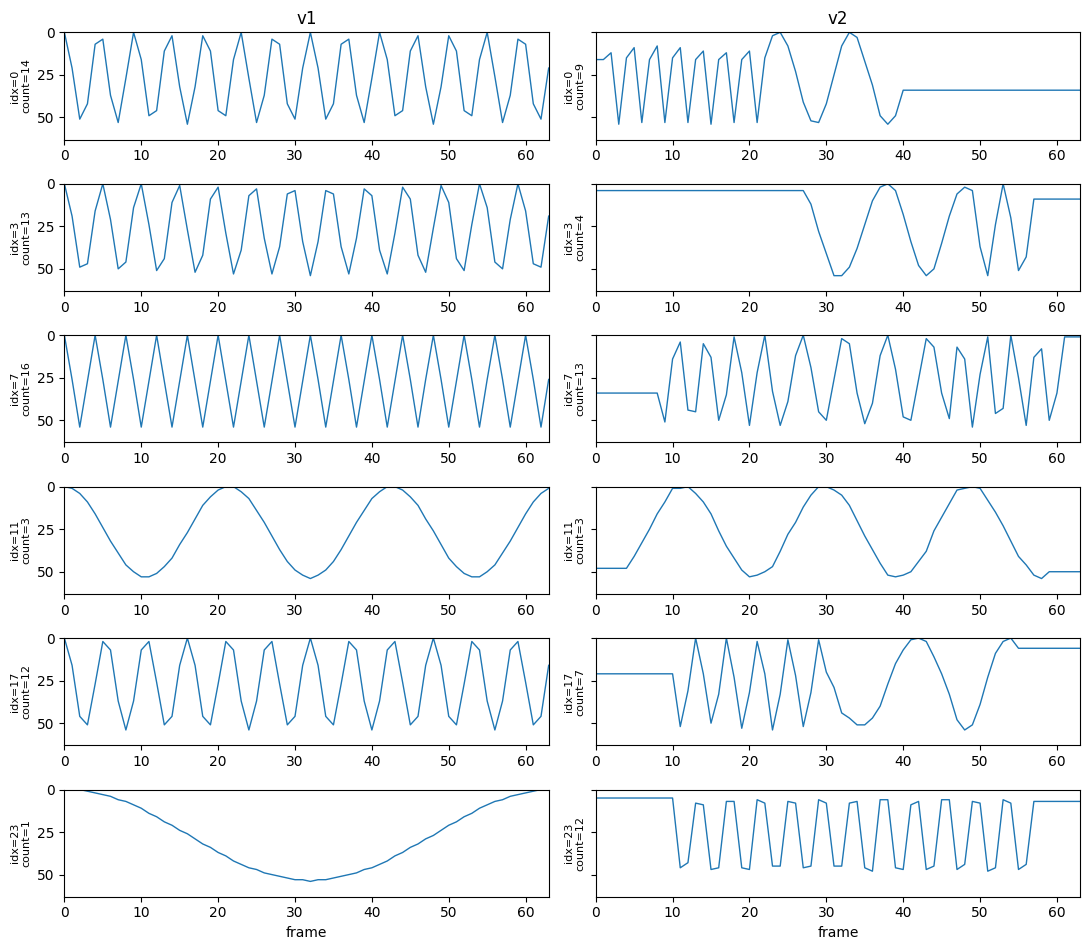

In [3]:
def extract_cy(clip, image_size):
    arr = clip.numpy()
    luminance = arr.mean(axis=1)
    cx = image_size // 2
    col = luminance[:, :, cx]
    return col.argmax(axis=1)


fig, axes = plt.subplots(
    len(INDICES), 2, figsize=(11, 1.6 * len(INDICES)), sharey=True
)
for r, idx in enumerate(INDICES):
    for c, (ds, name) in enumerate(((ds_v1, 'v1'), (ds_v2, 'v2'))):
        clip, count = ds[idx]
        cy = extract_cy(clip, IMAGE_SIZE)
        axes[r, c].plot(cy, color='tab:blue', lw=1.0)
        axes[r, c].set_xlim(0, N_FRAMES - 1)
        axes[r, c].set_ylim(IMAGE_SIZE - 1, 0)
        axes[r, c].set_ylabel(f'idx={idx}\ncount={count}', fontsize=8)
        if r == 0:
            axes[r, c].set_title(name)
        if r == len(INDICES) - 1:
            axes[r, c].set_xlabel('frame')
fig.tight_layout()
plt.show()

## Label distribution

v1 labels are uniform in `[1, max_count]` by construction. v2 labels are the sum of up to `max_segments` per-segment counts each uniform in `[1, max_count // n_seg]`, which produces a bell-shaped distribution peaked around `max_count / 2`. Worth being aware of when comparing OBO numbers.

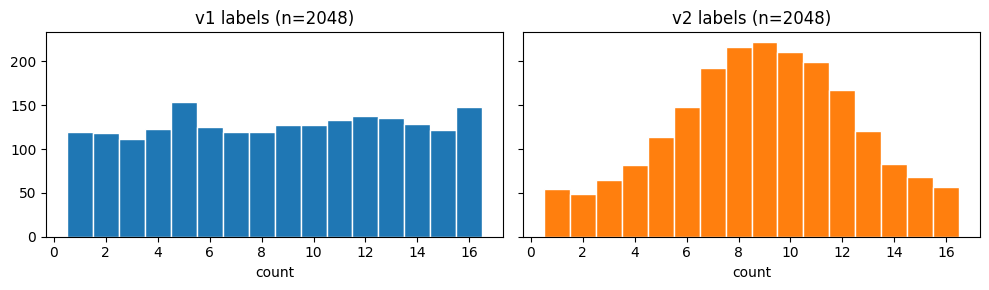

v1 mean=8.68  std=4.60  min=1  max=16
v2 mean=8.87  std=3.57  min=1  max=16


In [4]:
labels_v1 = np.array([int(ds_v1[i][1]) for i in range(len(ds_v1))])
labels_v2 = np.array([int(ds_v2[i][1]) for i in range(len(ds_v2))])

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
bins = np.arange(0.5, MAX_COUNT + 1.5, 1)
axes[0].hist(labels_v1, bins=bins, color='tab:blue', edgecolor='white')
axes[0].set_title(f'v1 labels (n={len(labels_v1)})')
axes[0].set_xlabel('count')
axes[1].hist(labels_v2, bins=bins, color='tab:orange', edgecolor='white')
axes[1].set_title(f'v2 labels (n={len(labels_v2)})')
axes[1].set_xlabel('count')
fig.tight_layout()
plt.show()

print(f'v1 mean={labels_v1.mean():.2f}  std={labels_v1.std():.2f}  min={labels_v1.min()}  max={labels_v1.max()}')
print(f'v2 mean={labels_v2.mean():.2f}  std={labels_v2.std():.2f}  min={labels_v2.min()}  max={labels_v2.max()}')